# IMPORTS + PATHS

In [2]:
# Core
import pandas as pd
import numpy as np
import os
import gc

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Vision
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# PATHS + LOAD DATA

In [3]:
BASE_PATH = "/kaggle/input/datasets/sm00ntaha/sentiment-data-final"

TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
TEST_CSV = os.path.join(BASE_PATH, "index_text_test.csv")

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH, "train_images-20260206T145842Z-1-001/train_images")
TEST_IMAGE_PATH = os.path.join(BASE_PATH, "test_images-20260206T145926Z-1-001/test_images")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.shape, test_df.shape)

(1061, 3) (133, 2)


# CLEAN TEXT

In [4]:
import re
import unicodedata

def clean_text_light(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text_light)
test_df['clean_text'] = test_df['text'].apply(clean_text_light)

# TEXT TF-IDF (5-FOLD OOF + TEST AVG)

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

text_oof_probs = np.zeros((len(train_df), 3))
text_test_probs = np.zeros((len(test_df), 3))

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):

    print(f"\nTEXT FOLD {fold+1}")

    X_train_text = train_df.iloc[train_idx]['clean_text']
    y_train = train_df.iloc[train_idx]['label']

    X_val_text = train_df.iloc[val_idx]['clean_text']
    y_val = train_df.iloc[val_idx]['label']

    word_vec = TfidfVectorizer(ngram_range=(1,2), max_features=3000)
    char_vec = TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=2000)

    word_vec.fit(X_train_text)
    char_vec.fit(X_train_text)

    from scipy.sparse import hstack

    X_train = hstack([word_vec.transform(X_train_text),
                      char_vec.transform(X_train_text)])

    X_val = hstack([word_vec.transform(X_val_text),
                    char_vec.transform(X_val_text)])

    X_test = hstack([word_vec.transform(test_df['clean_text']),
                     char_vec.transform(test_df['clean_text'])])

    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    text_oof_probs[val_idx] = model.predict_proba(X_val)
    text_test_probs += model.predict_proba(X_test) / 5

print("Text OOF ready")


TEXT FOLD 1

TEXT FOLD 2

TEXT FOLD 3

TEXT FOLD 4

TEXT FOLD 5
Text OOF ready


# SENTENCE TRANSFORMER (5-FOLD)

In [6]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

train_embeddings = st_model.encode(train_df['clean_text'].tolist(),
                                   batch_size=32,
                                   show_progress_bar=True)

test_embeddings = st_model.encode(test_df['clean_text'].tolist(),
                                  batch_size=32,
                                  show_progress_bar=True)

st_oof_probs = np.zeros((len(train_df), 3))
st_test_probs = np.zeros((len(test_df), 3))

for fold, (train_idx, val_idx) in enumerate(skf.split(train_embeddings, train_df['label'])):

    X_train = train_embeddings[train_idx]
    y_train = train_df['label'].values[train_idx]

    X_val = train_embeddings[val_idx]
    y_val = train_df['label'].values[val_idx]

    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    st_oof_probs[val_idx] = model.predict_proba(X_val)
    st_test_probs += model.predict_proba(test_embeddings) / 5

print("ST OOF ready")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

ST OOF ready


# FINE-TUNED IMAGE (5-FOLD, SAVE FOLD MODELS)

In [7]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['index']
        label = self.df.iloc[idx]['label']

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# Transform

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Model:

In [9]:
class EfficientNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Linear(in_features, 3)

    def forward(self, x):
        return self.backbone(x)

# Fold training + test averaging:

In [10]:
image_oof_probs = np.zeros((len(train_df), 3))
image_test_probs = np.zeros((len(test_df), 3))

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):

    print(f"\nIMAGE FOLD {fold+1}")

    train_split = train_df.iloc[train_idx]
    val_split = train_df.iloc[val_idx]

    train_ds = ImageDataset(train_split, TRAIN_IMAGE_PATH, train_transform)
    val_ds = ImageDataset(val_split, TRAIN_IMAGE_PATH, val_transform)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

    model = EfficientNetClassifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(4):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(val_loader):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            image_oof_probs[val_idx[i*16:(i*16+len(probs))]] = probs

    # Test predictions
    test_ds = ImageDataset(test_df.assign(label=0), TEST_IMAGE_PATH, val_transform)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

    fold_test_probs = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            fold_test_probs.append(probs)

    image_test_probs += np.vstack(fold_test_probs) / 5


IMAGE FOLD 1
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]



IMAGE FOLD 2

IMAGE FOLD 3

IMAGE FOLD 4

IMAGE FOLD 5


# STACKING META MODEL

In [11]:
meta_features = np.hstack([
    text_oof_probs,
    image_oof_probs,
    st_oof_probs
])

meta_model = LogisticRegression(max_iter=1000, class_weight='balanced')
meta_model.fit(meta_features, train_df['label'])

print("Stacking ready")

Stacking ready


In [12]:
from sklearn.metrics import f1_score

y_true = train_df['label'].values

# Convert probabilities to predictions
text_oof_preds = np.argmax(text_oof_probs, axis=1)
st_oof_preds = np.argmax(st_oof_probs, axis=1)
image_oof_preds = np.argmax(image_oof_probs, axis=1)

# Stacked OOF predictions
meta_oof_preds = meta_model.predict(meta_features)

# Compute Macro-F1
text_f1 = f1_score(y_true, text_oof_preds, average='macro')
st_f1 = f1_score(y_true, st_oof_preds, average='macro')
image_f1 = f1_score(y_true, image_oof_preds, average='macro')
stack_f1 = f1_score(y_true, meta_oof_preds, average='macro')

results_df = pd.DataFrame({
    "Model": [
        "TF-IDF (Lexical)",
        "SentenceTransformer (Semantic)",
        "EfficientNet (Image)",
        "Final Stacked Model"
    ],
    "CV Macro-F1": [
        text_f1,
        st_f1,
        image_f1,
        stack_f1
    ]
})

results_df

,Model,CV Macro-F1
0,TF-IDF (Lexical),0.383803
1,SentenceTransformer (Semantic),0.377410
2,EfficientNet (Image),0.378809
3,Final Stacked Model,0.423431


In [13]:
results_df.to_csv("model_comparison_table.csv", index=False)

In [14]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    meta_oof_preds,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

per_class_df = pd.DataFrame({
    "Class": ["Negative", "Neutral", "Positive"],
    "Precision": [
        report["Negative"]["precision"],
        report["Neutral"]["precision"],
        report["Positive"]["precision"]
    ],
    "Recall": [
        report["Negative"]["recall"],
        report["Neutral"]["recall"],
        report["Positive"]["recall"]
    ],
    "F1 Score": [
        report["Negative"]["f1-score"],
        report["Neutral"]["f1-score"],
        report["Positive"]["f1-score"]
    ]
})

per_class_df

,Class,Precision,Recall,F1 Score
0,Negative,0.444695,0.577713,0.502551
1,Neutral,0.537500,0.363636,0.433796
2,Positive,0.305369,0.368421,0.333945


In [15]:
per_class_df.to_csv("per_class_f1_table.csv", index=False)

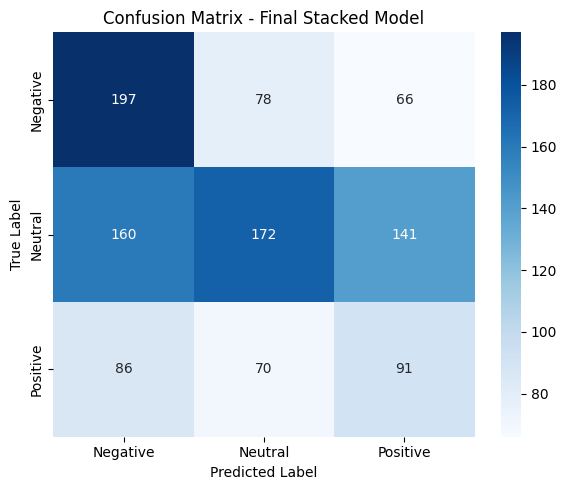

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, meta_oof_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Stacked Model")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [17]:
fold_f1_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (_, val_idx) in enumerate(skf.split(meta_features, y_true)):
    fold_preds = meta_oof_preds[val_idx]
    fold_true = y_true[val_idx]
    fold_score = f1_score(fold_true, fold_preds, average='macro')
    fold_f1_scores.append(fold_score)

fold_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Macro-F1": fold_f1_scores
})

fold_df

,Fold,Macro-F1
0,1,0.419271
1,2,0.421013
2,3,0.454797
3,4,0.407765
4,5,0.407215


# ABLATION STUDY: Modality Combination Analysis

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

y = train_df['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_combo(feature_matrix, y):
    oof_preds = np.zeros(len(y))
    
    for train_idx, val_idx in skf.split(feature_matrix, y):
        X_train, X_val = feature_matrix[train_idx], feature_matrix[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = LogisticRegression(max_iter=1000, class_weight='balanced')
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict(X_val)
    
    return f1_score(y, oof_preds, average='macro')


# TF-IDF + Image
combo_text_img = np.hstack([text_oof_probs, image_oof_probs])
f1_text_img = evaluate_combo(combo_text_img, y)

# SentenceTransformer + Image
combo_st_img = np.hstack([st_oof_probs, image_oof_probs])
f1_st_img = evaluate_combo(combo_st_img, y)

# TF-IDF + SentenceTransformer
combo_text_st = np.hstack([text_oof_probs, st_oof_probs])
f1_text_st = evaluate_combo(combo_text_st, y)

# All three (already computed)
f1_all = stack_f1

ablation_df = pd.DataFrame({
    "Model Combination": [
        "TF-IDF + Image",
        "SentenceTransformer + Image",
        "TF-IDF + SentenceTransformer",
        "TF-IDF + SentenceTransformer + Image"
    ],
    "Macro-F1": [
        f1_text_img,
        f1_st_img,
        f1_text_st,
        f1_all
    ]
})

ablation_df

,Model Combination,Macro-F1
0,TF-IDF + Image,0.387755
1,SentenceTransformer + Image,0.389698
2,TF-IDF + SentenceTransformer,0.371549
3,TF-IDF + SentenceTransformer + Image,0.423431


In [19]:
ablation_df.to_csv("ablation_study_table.csv", index=False)

# FINAL PREDICTIONS

In [20]:
meta_test = np.hstack([
    text_test_probs,
    image_test_probs,
    st_test_probs
])

final_preds = meta_model.predict(meta_test)

submission = pd.DataFrame({
    "index": test_df['index'],
    "label": final_preds
})

submission.to_csv("final_submission.csv", index=False)
submission.head()

,index,label
0,5485.jpg,2
1,5096.jpg,1
2,6021.jpg,1
3,5564.jpg,0
4,5743.jpg,0
